In [1]:
import time

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def exact_solution(d, w0, t):
    "Defines the analytical solution to the under-damped harmonic oscillator problem above."
    assert d < w0
    w = np.sqrt(w0**2-d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    cos = torch.cos(phi+w*t)
    exp = torch.exp(-d*t)
    u = exp*2*A*cos
    return u

class FCN(nn.Module):
    "Defines a fully-connected network in PyTorch"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

In [3]:
print("This is a module containing helper functions and classes for PINNs.")

This is a module containing helper functions and classes for PINNs.


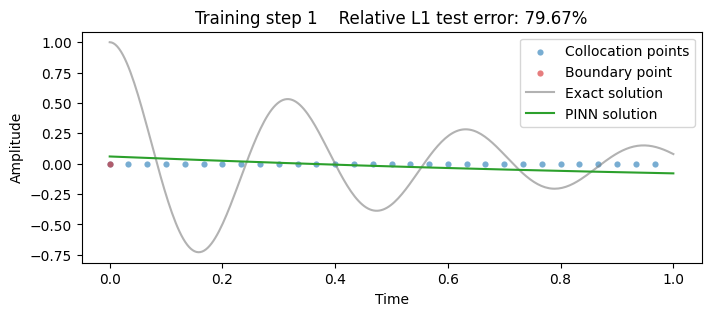

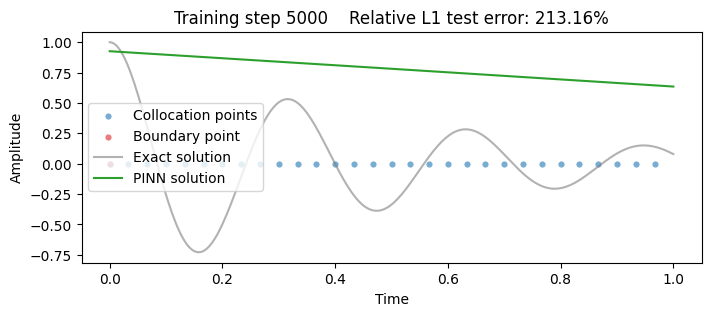

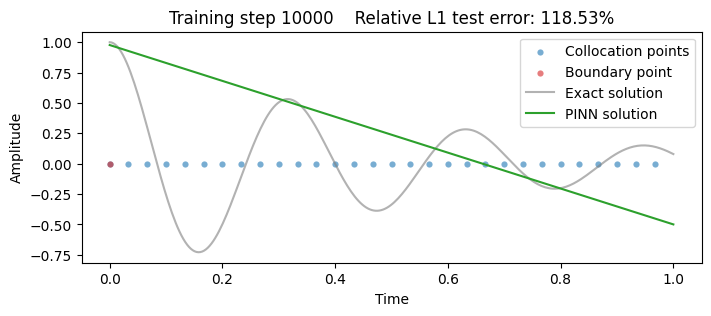

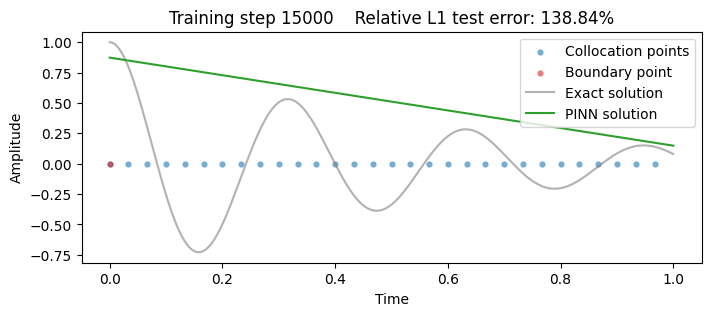

Total training time: 54.9803192615509 seconds


In [5]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,32,3)

# define boundary points, for the boundary loss
# TODO # (1, 1)
t_boundary = torch.tensor([[0.0]], requires_grad=True)

# define training points over the entire domain, for the physics loss
# TODO # (30, 1)
t_physics = torch.tensor([[i/30] for i in range(30)], requires_grad=True)

# train the PINN
d, w0 = 2, 20
mu, k = 2*d, w0**2
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)
optimiser = torch.optim.Adam(pinn.parameters(),lr=1e-3)
start = time.time()
for i in range(15000):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters
    lambda1, lambda2 = 1e-1, 1e-4

    # compute boundary loss
    # TODO
    u_boundary = pinn(t_boundary)
    loss1 = torch.mean((u_boundary - exact_solution(d, w0, t_boundary))**2)

    # compute physics loss
    # TODO
    u_physics = pinn(t_physics)
    loss2 = torch.mean((u_physics - exact_solution(d, w0, t_physics))**2)

    loss3 = torch.mean((torch.autograd.grad(u_physics, t_physics,
                                            grad_outputs=torch.ones_like(u_physics),
                                            create_graph=True)[0]
                        + mu*u_physics
                        + k*torch.autograd.grad(torch.autograd.grad(u_physics, t_physics,
                                                                    grad_outputs=torch.ones_like(u_physics),
                                                                    create_graph=True)[0],
                                                t_physics,
                                                grad_outputs=torch.ones_like(u_physics),
                                                create_graph=True)[0])**2)**2  
    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2 + lambda2*loss3
    loss.backward()
    optimiser.step()

    # plot the result as training progresses
    if (i+1)%5000 == 0 or i==0:
        u = pinn(t_test).detach()
        test_error = torch.mean(torch.abs(u-u_exact)/u_exact.std())
        plt.figure(figsize=(8,3))
        plt.scatter(t_physics.detach()[:,0], torch.zeros_like(t_physics)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
        plt.scatter(t_boundary.detach()[:,0], 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point")
        plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.title(f"Training step {i+1}    Relative L1 test error: {test_error:.2%}")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time()-start} seconds")

True value of mu: 4


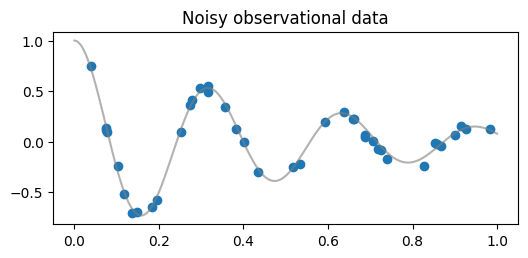

In [6]:
# first, create some noisy observational data
torch.manual_seed(123)
d, w0 = 2, 20
print(f"True value of mu: {2*d}")
t_obs = torch.rand(40).view(-1,1)
u_obs = exact_solution(d, w0, t_obs) + 0.04*torch.randn_like(t_obs)
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)

plt.figure(figsize=(6,2.5))
plt.title("Noisy observational data")
plt.scatter(t_obs[:,0], u_obs[:,0])
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.show()

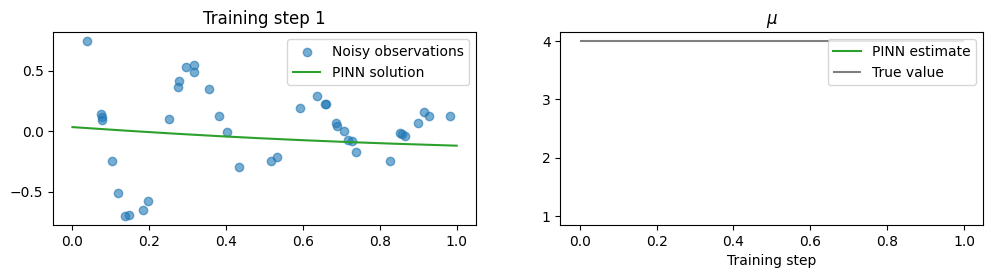

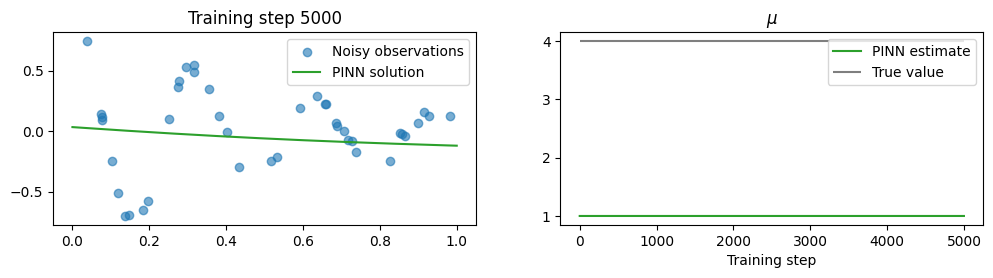

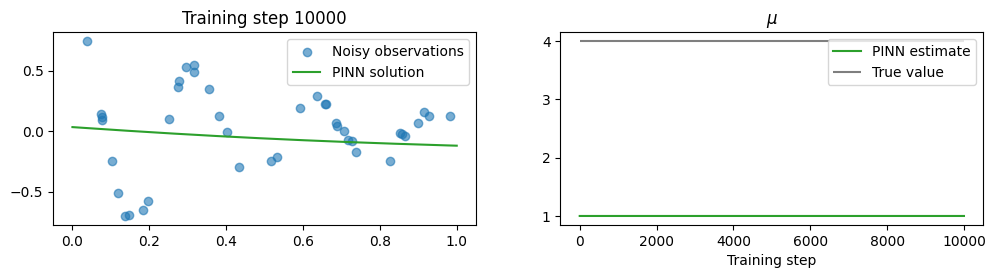

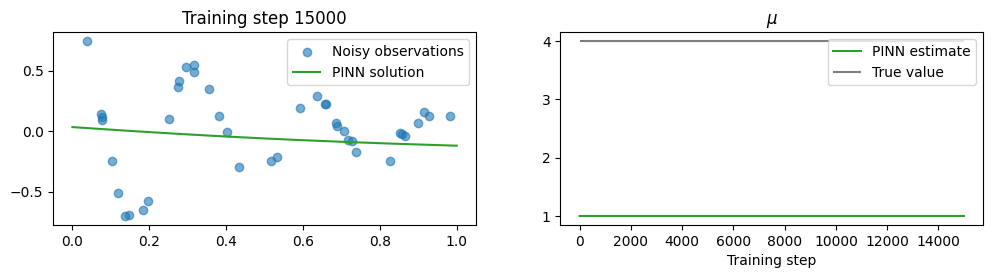

In [8]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,32,3)

# define training points over the entire domain, for the physics loss
t_physics = torch.linspace(0,1,50).view(-1,1).requires_grad_(True)# (50, 1)

# train the PINN
d, w0 = 2, 20
mu, k = 2*d, w0**2
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)

# treat mu as a learnable parameter, add it to optimiser
# TODO
mu = torch.nn.Parameter(torch.tensor([1.0]), requires_grad=True)

mus = []
for i in range(15000):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters
    lambda1 = 1e4

    # compute physics loss
    u = pinn(t_physics)# (50, 1)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]# (50, 1)
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]# (50, 1)
    loss1 = torch.mean((d2udt2 + mu*dudt + k*u)**2)

    # compute data loss
    # TODO
    u_data = pinn(t_obs)
    loss2 = torch.mean((u_data - u_obs)**2)
    
      

    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2
    loss.backward()
    optimiser.step()

    # record mu value
    mus.append(mu.item())

    # plot the result as training progresses
    if (i+1)%5000 == 0 or i==0:
        u = pinn(t_test).detach()
        plt.figure(figsize=(12,2.5))

        plt.subplot(1,2,1)
        plt.scatter(t_obs[:,0], u_obs[:,0], label="Noisy observations", alpha=0.6, color="tab:blue")
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i+1}")
        plt.legend()

        plt.subplot(1,2,2)
        plt.title("$\\mu$")
        plt.plot(mus, label="PINN estimate", color="tab:green")
        plt.hlines(2*d, 0, len(mus), label="True value", color="tab:grey")
        plt.xlabel("Training step")
        plt.legend()

        plt.show()